In [1]:
import numpy as np
import bayesflow as bf
import keras
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import pickle
from benchmark.examples.gaussian.approximators.simulator import Simulator    
from benchmark.examples.gaussian.approximators.approximators import BayesFLowNPE 
from benchmark.examples.gaussian.datasets.stan_dataset import  StanDataset
from benchmark.examples.gaussian.datasets.calculation import Calculation
from benchmark.examples.gaussian.datasets.analysis import Analysis

INFO:bayesflow:Using backend 'jax'


In [2]:
RNG=np.random.default_rng(2025)
mu_prior_mean=0
mu_prior_std=1
num_dims=5
num_obs=100
likelihood_std=1

In [4]:
simulator_bayes=Simulator(mu_prior_mean=mu_prior_mean, mu_prior_std=mu_prior_std, 
                          num_dims=num_dims, num_obs=num_obs,
                          likelihood_std=likelihood_std,
                          use_student_t=True,df=10,rng=RNG)
simulator=simulator_bayes.get_bayes_simulator()
bayesflownpe=BayesFLowNPE(simulator=simulator)
bayesflownpe._build_workflow()
history=bayesflownpe.train(epochs=100,batch_size=64,num_batches_per_epoch=200)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 26s 81ms/step - loss: 4.8191
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - loss: 3.1513
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - loss: 2.1945
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - loss: 1.3658
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - loss: 0.9490
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - loss: 0.4166
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - loss: -0.1530
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - loss: -0.6381
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - loss: -0.9243
Epoch 10/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - loss: -1.1629
Epoch 11/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 19s 96ms/step - loss: -1.3848
Epoch 12/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - loss: -1.6321
Epoch 13/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - loss: -1.7227
Epoch 14/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - loss: -1.8974
Epoch 1

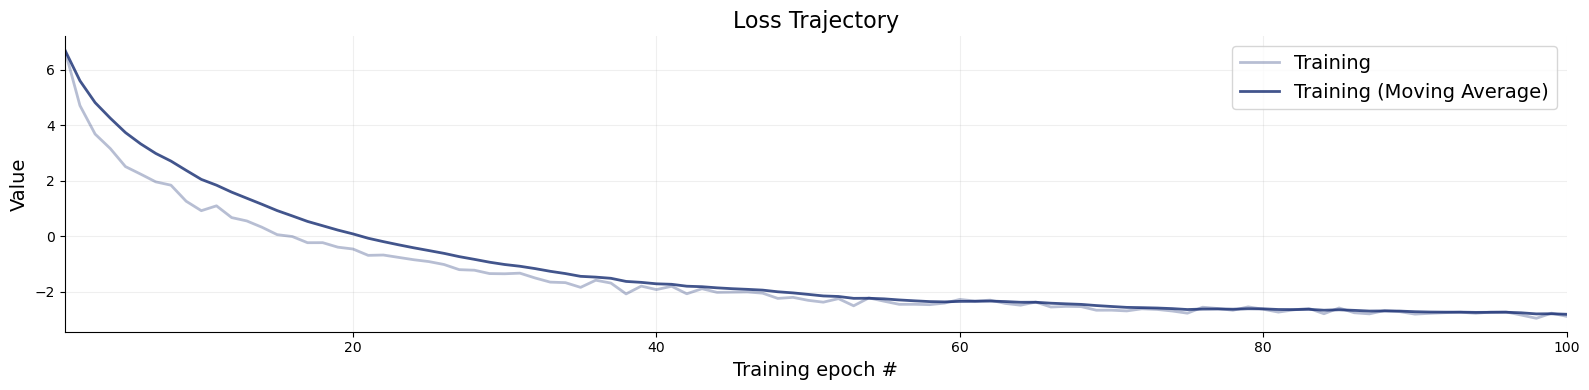

In [5]:
f=bf.diagnostics.plots.loss(history)

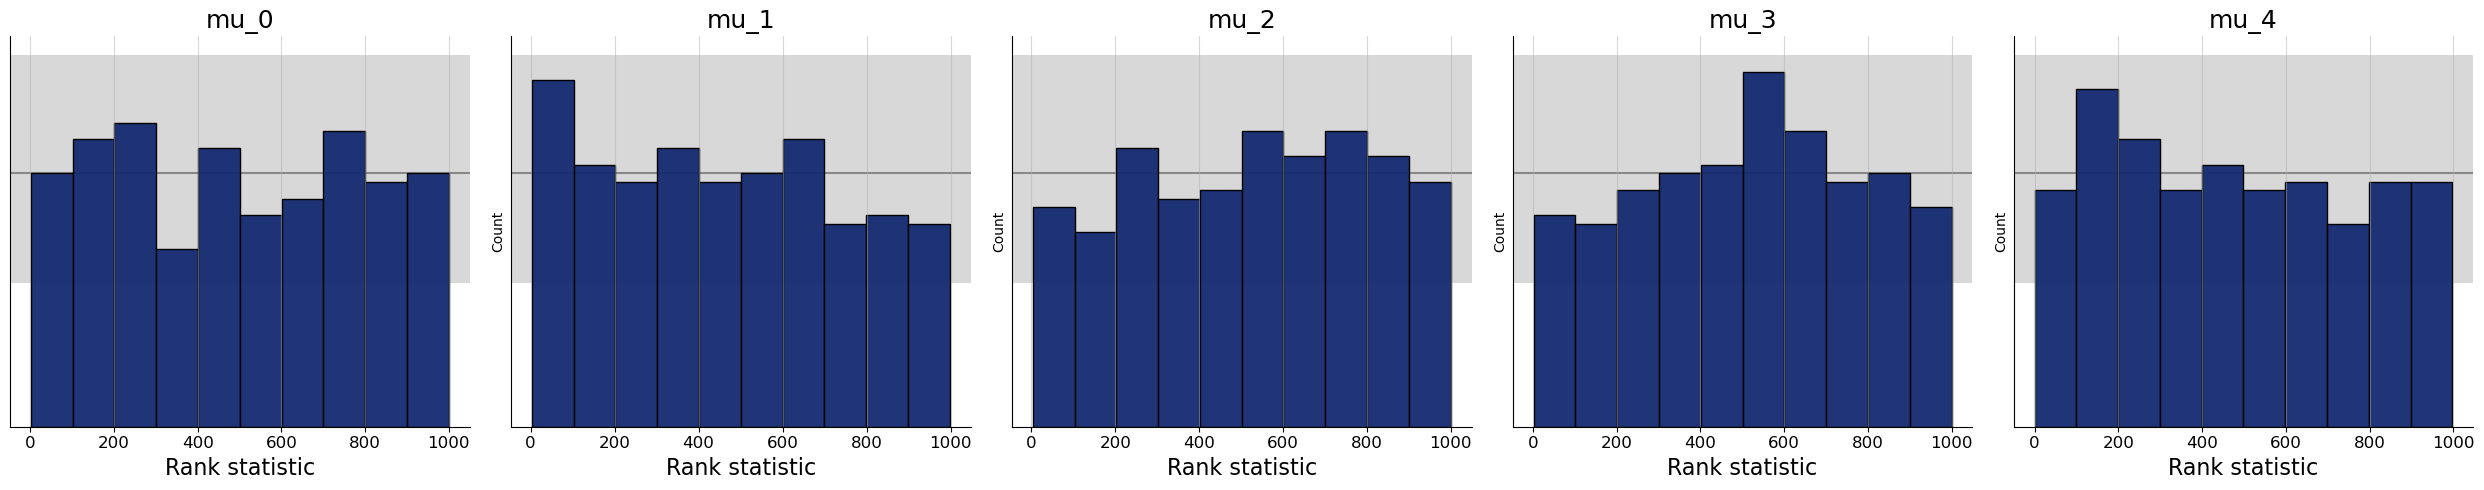

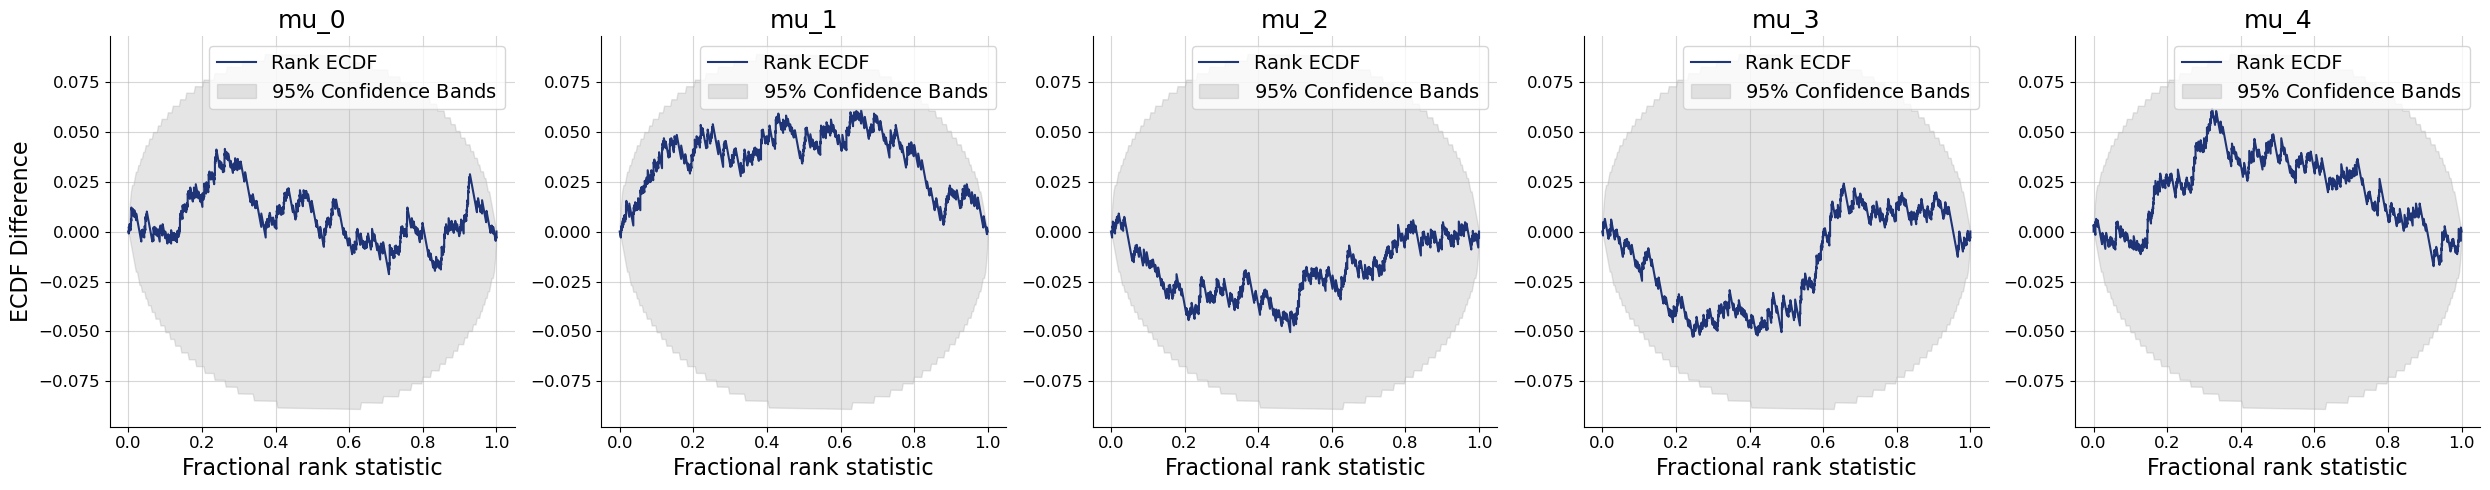

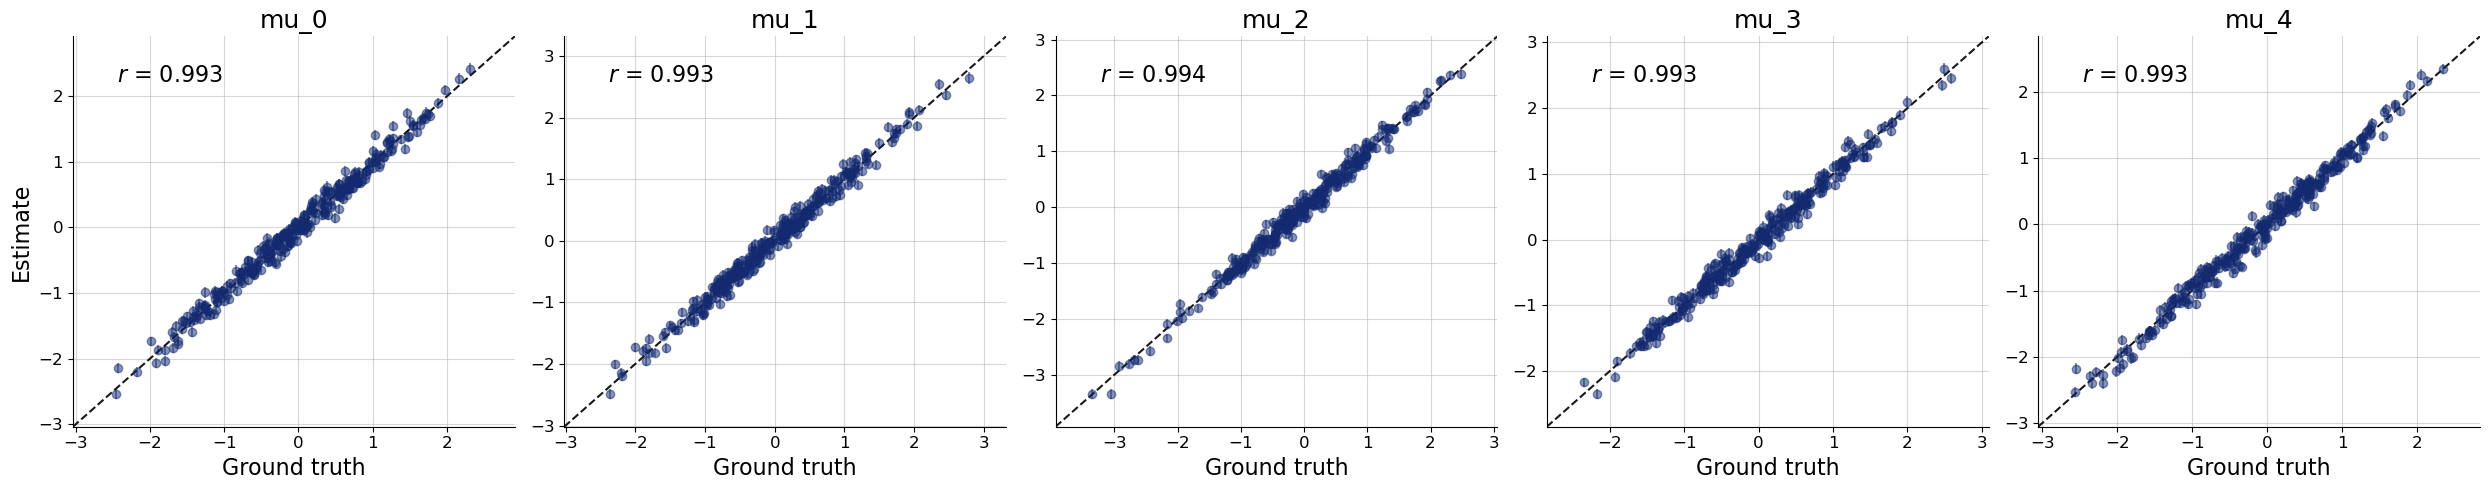

In [5]:
# Generate test datasets and get posterior samples and perform diagnostics
test_sims, posterior_samples = bayesflownpe.test_datasets(number_datasets=300, num_samples=1000)
f1 = bf.diagnostics.plots.calibration_histogram(posterior_samples, test_sims)
f2 = bf.diagnostics.plots.calibration_ecdf(posterior_samples, test_sims,difference=True)
f3 = bf.diagnostics.plots.recovery(posterior_samples, test_sims)

In [8]:
# Save the trained approximator
filepath = Path("/Users/mandyking/benchmark/benchmark/examples/gaussian/networks") / "npe_student_df10.keras"
filepath.parent.mkdir(exist_ok=True)
bayesflownpe.workflow.approximator.save(filepath=filepath)

In [ ]:
# Load the trained approximator
filepath = Path("/Users/mandyking/benchmark/benchmark/examples/gaussian/networks") / "npe_student_df10.keras"
approximator=keras.saving.load_model(filepath)
simulator_bayes=Simulator(mu_prior_mean=mu_prior_mean, mu_prior_std=mu_prior_std, 
                          num_dims=num_dims, num_obs=num_obs,
                          likelihood_std=likelihood_std,
                          use_student_t=True,df=10,rng=RNG)
simulator=simulator_bayes.get_bayes_simulator()
bayesflownpe=BayesFLowNPE(simulator=simulator)
bayesflownpe.workflow.approximator=approximator

In [9]:
# load json for student_t datasets
datasets_normal_0=StanDataset.load_datasets_from_json(dir_path="/Users/mandyking/benchmark/benchmark/examples/gaussian/stan/stan_output_n0")
datasets_normal_10=StanDataset.load_datasets_from_json(dir_path="/Users/mandyking/benchmark/benchmark/examples/gaussian/stan/stan_output_n10")
datasets_student=StanDataset.load_datasets_from_json(dir_path="/Users/mandyking/benchmark/benchmark/examples/gaussian/stan/stan_output_df10")

In [ ]:
print(datasets_normal_10[0].keys())
print(datasets_normal_0[0]["gold_log_marginal"])

In [10]:
calculation=Calculation(workflow=bayesflownpe,mu_prior_mean=mu_prior_mean, mu_prior_std=mu_prior_std,
                        num_dims=num_dims,num_obs=num_obs,
                        likelihood_std=likelihood_std,num_samples=1000,
                        use_student_t=True,df=10)
datasets_normal_0=calculation.npe_estimation(obs_data=datasets_normal_0)
datasets_normal_10=calculation.npe_estimation(obs_data=datasets_normal_10)
datasets_student=calculation.npe_estimation(obs_data=datasets_student)

In [ ]:
# read datasets
def load_pickle(path: str):
    with open(path, "rb") as f:
        return pickle.load(f)

datasets_normal_0  = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/03datasets_normal_0.pkl")
datasets_normal_10 = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/03datasets_normal_10.pkl")
datasets_student   = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/03datasets_student_df10.pkl")



In [11]:
# save datasetst
def save_pickle(obj, path: str):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(obj, f)

save_pickle(datasets_normal_0,  "/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/03datasets_normal_0.pkl")
save_pickle(datasets_normal_10, "/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/03datasets_normal_10.pkl")
save_pickle(datasets_student,   "/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/03datasets_student_df10.pkl")

In [35]:
# calculate mmd and abs_error_lm for each type of datasets
group_specs = [
    (r"$M_1$", datasets_normal_0),   
    (r"$M_2$", datasets_normal_10),
    (r"$M_3$", datasets_student),   
]
metrics = pd.concat(
    [Analysis.evaluate_mmd_err(ds_list, name) for name, ds_list in group_specs],
    ignore_index=True
)


In [36]:
summary = (metrics
           .groupby("dataset_group")[["mmd", "abs_logml_error"]]
           .agg(["mean", "median", "std", "min", "max"])
           .reset_index())
print(summary)


  dataset_group       mmd                                          \
                     mean    median       std       min       max   
0         $M_1$  0.021256  0.018354  0.009931  0.010610  0.061097   
1         $M_2$  1.944179  1.942666  0.049114  1.839717  2.058206   
2         $M_3$  0.025017  0.024994  0.008214  0.012160  0.046124   

  abs_logml_error                                                     
             mean       median         std          min          max  
0        0.016234     0.013344    0.014208     0.000224     0.083967  
1     3094.634722  3089.280803  301.586945  2478.645055  3794.722429  
2        0.016694     0.015551    0.013600     0.000111     0.065405  


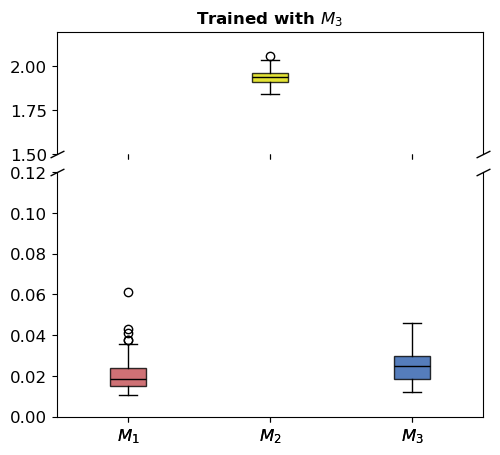

In [45]:
#plot MMD
from matplotlib.patches import Patch
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold"
})

groups = [r"$M_1$",r"$M_2$",r"$M_3$"]
data = [metrics.loc[metrics["dataset_group"]==g,"mmd"]
        .dropna().astype(float).values for g in groups]

fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(5.5,5),
    gridspec_kw={"height_ratios":[1,2]}
)

colors = [ "#C44E52","#DDDD04","#2A5CAB"]

bp1 = ax1.boxplot(data, tick_labels=groups,
                   showfliers=True,
                  patch_artist=True,
                  widths=0.25,
                  medianprops=dict(color='black', linewidth=1)
                  )

bp2 = ax2.boxplot(data, tick_labels=groups,
                   showfliers=True,
                  patch_artist=True,
                  widths=0.25,
                  medianprops=dict(color='black', linewidth=1))

for bp in [bp1, bp2]:
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)


ax1.set_ylim(1.5, 2.2)     
ax2.set_ylim(0.0, 0.12)  

ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax1.tick_params(labeltop=False, labelsize=12)
ax2.tick_params(labelsize=12)
ax2.xaxis.tick_bottom()

d = 0.5
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=10,
              linestyle="none", color="k",
              mec="k", mew=1, clip_on=False)

ax1.plot([0,1], [0,0], transform=ax1.transAxes, **kwargs)
ax2.plot([0,1], [1,1], transform=ax2.transAxes, **kwargs)
ax2.yaxis.set_label_coords(-0.12, 0.7)
ax1.set_title(
    r"Trained with $M_3$",
    fontsize=12,
    
)

plt.subplots_adjust(hspace=0.1)
plt.show()

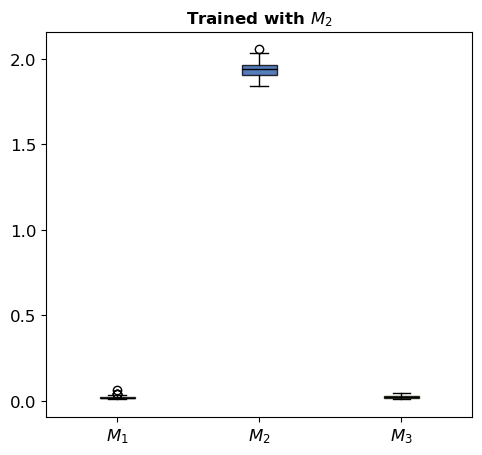

In [47]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold"
})

groups = [name for name, _ in group_specs]

data = []
for g in groups:
    s = metrics.loc[metrics["dataset_group"] == g, "mmd"]
    arr = pd.to_numeric(s, errors="coerce").dropna().astype(float).tolist()
    data.append(arr)

colors = ["#55A868","#2A5CAB", "#DDDD04",]

fig, ax = plt.subplots(figsize=(5.5, 5))

bp = ax.boxplot(
    data,
    tick_labels=groups,
    patch_artist=True,
    widths=0.25,
    medianprops=dict(color='black', linewidth=1)
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)


ax.set_title(
    r"Trained with $M_2$",
    fontsize=12
)

plt.subplots_adjust(hspace=0.1)
plt.show()

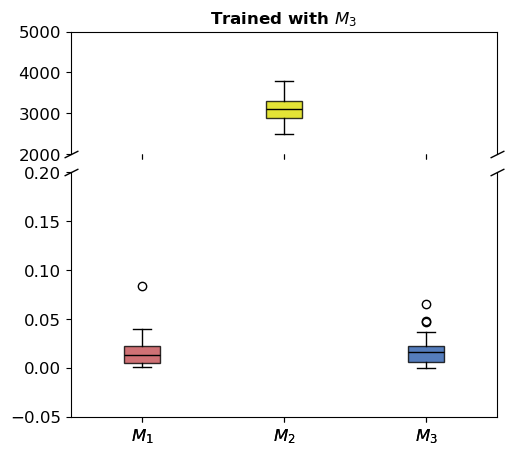

In [46]:
# plot logml
groups = [r"$M_1$",r"$M_2$",r"$M_3$"]
data = [metrics.loc[metrics["dataset_group"]==g,"abs_logml_error"]
        .dropna().astype(float).values for g in groups]

fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(5.5,5),
    gridspec_kw={"height_ratios":[1,2]}
)

colors = [ "#C44E52","#DDDD04","#2A5CAB"]

bp1 = ax1.boxplot(data, tick_labels=groups,
                   showfliers=True,
                  patch_artist=True,
                  widths=0.25,
                  medianprops=dict(color='black', linewidth=1)
                  )

bp2 = ax2.boxplot(data, tick_labels=groups,
                   showfliers=True,
                  patch_artist=True,
                  widths=0.25,
                  medianprops=dict(color='black', linewidth=1))

for bp in [bp1, bp2]:
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)


ax1.set_ylim(2000,5000)     
ax2.set_ylim(-0.05,0.2)   

ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax1.tick_params(labeltop=False, labelsize=12)
ax2.tick_params(labelsize=12)
ax2.xaxis.tick_bottom()

d = 0.5
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=10,
              linestyle="none", color="k",
              mec="k", mew=1, clip_on=False)

ax1.plot([0,1], [0,0], transform=ax1.transAxes, **kwargs)
ax2.plot([0,1], [1,1], transform=ax2.transAxes, **kwargs)
ax2.yaxis.set_label_coords(-0.12, 0.7)
ax1.set_title(
    r"Trained with $M_3$",
    fontsize=12,
    
)

plt.subplots_adjust(hspace=0.1)
plt.show()

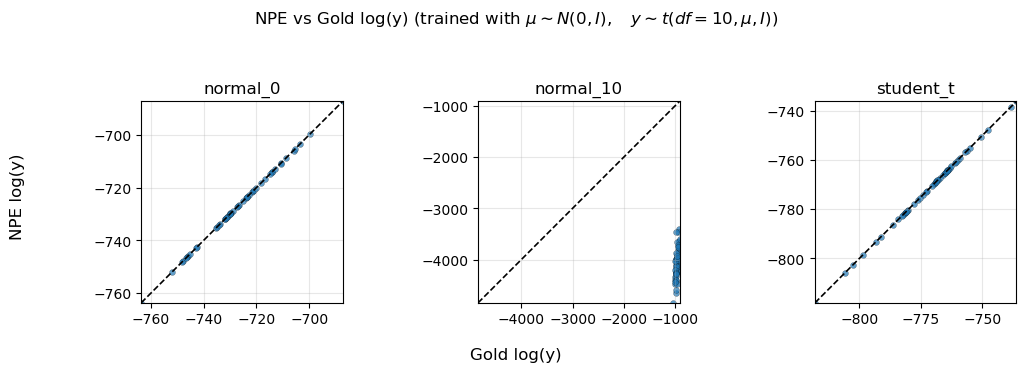

In [ ]:
groups = ["normal_0", "normal_10", "student_t"]
xcol = "gold_logml"
ycol = "npe_logml"

fig, ax = plt.subplots(1, len(groups), figsize=(11, 3.6), sharey=False)

if len(groups) == 1:
    ax = [ax]

for i, g in enumerate(groups):
    sub = metrics.loc[metrics["dataset_group"] == g, [xcol, ycol]].dropna()
    x = sub[xcol].astype(float).to_numpy()
    y = sub[ycol].astype(float).to_numpy()
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    ax[i].scatter(x, y, s=18, alpha=0.7, marker="o", edgecolors="k", linewidths=0.2)
    ax[i].plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1.2)
    ax[i].set_xlim(lo, hi)
    ax[i].set_ylim(lo, hi)
    ax[i].set_aspect("equal", adjustable="box")
    ax[i].grid(True, alpha=0.3)
    ax[i].set_title(g)
fig.supxlabel("Gold log(y)", y=0.04)
fig.supylabel("NPE log(y)", x=0.04)
fig.suptitle(r"NPE vs Gold log(y) (trained with $\mu \sim N(0, I), \quad y \sim t(df=10, \mu, I)$)", y=1.02)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.92])
plt.show()